# 340 String MC effective area


In [137]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from Metadata.paths import TRIGGERED_EVENT_LIST

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## Load weight files

The four String340MC weight files are loaded separately so flavor labels stay explicit throughout the notebook.

In [138]:
DATA_DIR = Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC")

weight_files = {
    "electron": next(DATA_DIR.glob("Electron_*.csv")),
    "muon": next(DATA_DIR.glob("Muon_*.csv")),
    "nc": next(DATA_DIR.glob("NC_*.csv")),
    "tau": next(DATA_DIR.glob("Tau_*.csv")),
}

flavor_weights = {
    flavor: pd.read_csv(path)
    for flavor, path in weight_files.items()
}

## Split and normalize weights

Each flavor is split into neutrino and antineutrino samples using `initialType`. The normalized `oneweight` is built from `oneweight_x100`, then `final_weight` applies the event survival probability.

In [139]:
def split_neutrino_samples(weights):
    return {
        "neutrino": weights.loc[weights["initialType"] > 0].copy(),
        "antineutrino": weights.loc[weights["initialType"] < 0].copy(),
    }


def add_analysis_weights(sample):
    if sample.empty:
        raise ValueError("Cannot normalize an empty neutrino sample.")

    weighted = sample.copy()
    weighted["oneweight"] = weighted["oneweight_x100"] / len(weighted)
    weighted = weighted.drop(columns=["oneweight_x100"])
    weighted["final_weight"] = weighted["oneweight"] * weighted["survivalProb"]
    return weighted


flavor_splits = {
    flavor: split_neutrino_samples(weights)
    for flavor, weights in flavor_weights.items()
}

weighted_flavor_splits = {
    flavor: {
        particle_type: add_analysis_weights(sample)
        for particle_type, sample in samples.items()
    }
    for flavor, samples in flavor_splits.items()
}

# Convenient names for quick interactive inspection.
electron_neutrino = weighted_flavor_splits["electron"]["neutrino"]
electron_antineutrino = weighted_flavor_splits["electron"]["antineutrino"]
muon_neutrino = weighted_flavor_splits["muon"]["neutrino"]
muon_antineutrino = weighted_flavor_splits["muon"]["antineutrino"]
nc_neutrino = weighted_flavor_splits["nc"]["neutrino"]
nc_antineutrino = weighted_flavor_splits["nc"]["antineutrino"]
tau_neutrino = weighted_flavor_splits["tau"]["neutrino"]
tau_antineutrino = weighted_flavor_splits["tau"]["antineutrino"]

## Triggered event lists

Triggered event lists are loaded for each flavor and merged with the weighted event samples using event identifiers.

In [140]:
triggered_event_paths = {
    "electron": TRIGGERED_EVENT_LIST["String340MC"]["102_string"]["Electron"],
    "muon": TRIGGERED_EVENT_LIST["String340MC"]["102_string"]["Muon"],
    "nc": TRIGGERED_EVENT_LIST["String340MC"]["102_string"]["NC"],
    "tau": TRIGGERED_EVENT_LIST["String340MC"]["102_string"]["Tau"],
}

triggered_events = {
    flavor: pd.read_csv(path)
    for flavor, path in triggered_event_paths.items()
}

common_columns = ["EventID", "SubEventID", "RunID", "SubrunID"]

triggered_weighted_flavor_splits = {}

for flavor, samples in weighted_flavor_splits.items():
    triggered_weighted_flavor_splits[flavor] = {}

    for particle_type, sample in samples.items():
        triggered_weighted_flavor_splits[flavor][particle_type] = sample.merge(
            triggered_events[flavor],
            on=common_columns,
            how="inner",
        )

In [141]:
triggered_summary = pd.DataFrame(
    [
        {
            "flavor": flavor,
            "particle_type": particle_type,
            "n_generated": len(weighted_flavor_splits[flavor][particle_type]),
            "n_triggered": len(triggered_weighted_flavor_splits[flavor][particle_type]),
        }
        for flavor in weighted_flavor_splits
        for particle_type in weighted_flavor_splits[flavor]
    ]
)

triggered_summary

,flavor,particle_type,n_generated,n_triggered
0,electron,neutrino,686609,30662
1,electron,antineutrino,684900,30495
2,muon,neutrino,975991,102417
3,muon,antineutrino,964338,101509
4,nc,neutrino,998786,32298
5,nc,antineutrino,999483,29337
6,tau,neutrino,997251,45681
7,tau,antineutrino,995304,45766


## Effective area and MC uncertainty

For each flavor, neutrino and antineutrino samples are binned in true energy. The plotted effective area is

$$
A_{\mathrm{eff}}(E) = \frac{\sum_{i \in E\,\mathrm{bin}} w_i}{\Delta E\,\Delta\Omega}.
$$

The MC uncertainty estimate is

$$
\sigma_{A_{\mathrm{eff}}}(E) = \frac{\sqrt{\sum_{i \in E\,\mathrm{bin}} w_i^2}}{\Delta E\,\Delta\Omega}.
$$

Here `w_i = final_weight_i`, and $\Delta\Omega = 4\pi$ for the all-sky average. Since `final_weight` has units of `GeV sr cm^2`, dividing by `Delta E` and `Delta Omega` first gives `cm^2`; the plotted values are converted to `m^2` by dividing by `1e4`.

Energy bins are built separately for each flavor from that flavor's generation-level energy range. This avoids the artificial high-energy edge effect that appeared when the muon energy range forced global bins beyond the electron, tau, and NC ranges.

In [142]:
flavor_plot_order = ["nc", "electron", "tau", "muon"]
flavor_colors = {
    "nc": "tab:gray",
    "electron": "tab:blue",
    "tau": "tab:green",
    "muon": "tab:orange",
}
flavor_display_labels = {
    "nc": r"NC",
    "electron": r"CC $\nu_e$",
    "tau": r"CC $\nu_\tau$",
    "muon": r"CC $\nu_\mu$",
}
particle_styles = {
    "neutrino": "-",
    "antineutrino": "--",
}
particle_display_labels = {
    "neutrino": r"$\nu$",
    "antineutrino": r"$\bar{\nu}$",
}
particle_colors = {
    "neutrino": "tab:blue",
    "antineutrino": "tab:orange",
}
level_colors = {
    "triggered": "tab:blue",
    "generation level": "tab:orange",
}
solid_angle = 4 * np.pi
cm2_to_m2 = 1e-4


def make_flavor_energy_bins(samples, n_bins=30):
    energies = pd.concat(
        [sample.loc[sample["energy"] > 0, "energy"] for sample in samples.values()],
        ignore_index=True,
    )
    return np.logspace(np.log10(energies.min()), np.log10(energies.max()), n_bins)


flavor_energy_bins = {
    flavor: make_flavor_energy_bins(weighted_flavor_splits[flavor])
    for flavor in flavor_plot_order
}


def calculate_effective_area(sample, bins, weight_column="final_weight", solid_angle=4 * np.pi):
    plot_sample = sample.loc[(sample["energy"] > 0) & (sample[weight_column] > 0)]
    bin_widths = np.diff(bins)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])

    weighted_sum, _ = np.histogram(
        plot_sample["energy"],
        bins=bins,
        weights=plot_sample[weight_column],
    )
    weighted_sum_sq, _ = np.histogram(
        plot_sample["energy"],
        bins=bins,
        weights=plot_sample[weight_column] ** 2,
    )

    norm = bin_widths * solid_angle
    effective_area_cm2 = weighted_sum / norm
    uncertainty_cm2 = np.sqrt(weighted_sum_sq) / norm
    effective_area = effective_area_cm2 * cm2_to_m2
    uncertainty = uncertainty_cm2 * cm2_to_m2
    return bin_centers, effective_area, uncertainty


def plot_area_curve(ax, centers, area, uncertainty, *, label, color, linestyle="-"):
    positive = area > 0
    x = centers[positive]
    y = area[positive]
    sigma = uncertainty[positive]
    lower = np.clip(y - sigma, 1e-300, None)
    upper = y + sigma

    ax.fill_between(
        x,
        lower,
        upper,
        color=color,
        alpha=0.12,
        linewidth=0,
        zorder=1,
    )
    ax.plot(
        x,
        lower,
        color=color,
        linestyle=":",
        linewidth=0.8,
        alpha=0.55,
        zorder=2,
    )
    ax.plot(
        x,
        upper,
        color=color,
        linestyle=":",
        linewidth=0.8,
        alpha=0.55,
        zorder=2,
    )
    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyle,
        linewidth=1.9,
        label=label,
        zorder=3,
    )


def style_effective_area_axes(fig, axes, title, ylabel=r"$A_{\mathrm{eff}}$ [m$^2$]"):
    for ax in axes:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(frameon=False)

    for ax in axes[2:]:
        ax.set_xlabel("True energy")
    for ax in axes[::2]:
        ax.set_ylabel(ylabel)

    fig.suptitle(title, y=1.02)
    fig.tight_layout()


def style_relative_uncertainty_axes(fig, axes, title):
    for ax in axes:
        ax.set_xscale("log")
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(frameon=False)

    for ax in axes[2:]:
        ax.set_xlabel("True energy")
    for ax in axes[::2]:
        ax.set_ylabel("Relative statistical uncertainty")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()


def plot_effective_area_by_flavor(sample_splits, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True)
    axes = axes.ravel()

    for ax, flavor in zip(axes, flavor_plot_order):
        bins = flavor_energy_bins[flavor]

        for particle_type, linestyle in particle_styles.items():
            centers, area, uncertainty = calculate_effective_area(
                sample_splits[flavor][particle_type],
                bins,
            )
            plot_area_curve(
                ax,
                centers,
                area,
                uncertainty,
                label=particle_display_labels[particle_type],
                color=particle_colors[particle_type],
                linestyle=linestyle,
            )

        ax.set_title(flavor_display_labels[flavor])

    style_effective_area_axes(fig, axes, title)
    plt.show()


def combined_effective_area(samples, bins):
    combined_area = None
    combined_variance = None
    centers = None

    for sample in samples.values():
        centers, area, uncertainty = calculate_effective_area(sample, bins)
        variance = uncertainty**2

        if combined_area is None:
            combined_area = area.copy()
            combined_variance = variance.copy()
        else:
            combined_area += area
            combined_variance += variance

    return centers, combined_area, np.sqrt(combined_variance)


def plot_triggered_vs_generation(triggered_splits, generation_splits, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True)
    axes = axes.ravel()

    for ax, flavor in zip(axes, flavor_plot_order):
        bins = flavor_energy_bins[flavor]
        centers, triggered_area, triggered_uncertainty = combined_effective_area(
            triggered_splits[flavor],
            bins,
        )
        _, generation_area, generation_uncertainty = combined_effective_area(
            generation_splits[flavor],
            bins,
        )

        plot_area_curve(
            ax,
            centers,
            triggered_area,
            triggered_uncertainty,
            label="triggered",
            color=level_colors["triggered"],
        )
        plot_area_curve(
            ax,
            centers,
            generation_area,
            generation_uncertainty,
            label="generation level",
            color=level_colors["generation level"],
        )

        ax.set_title(flavor_display_labels[flavor])

    style_effective_area_axes(
        fig,
        axes,
        title,
        ylabel=r"$A_{\mathrm{eff},\nu+\bar{\nu}}$ [m$^2$]",
    )
    plt.show()


def plot_relative_uncertainty_triggered_vs_generation(triggered_splits, generation_splits, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True)
    axes = axes.ravel()

    for ax, flavor in zip(axes, flavor_plot_order):
        bins = flavor_energy_bins[flavor]
        centers, triggered_area, triggered_uncertainty = combined_effective_area(
            triggered_splits[flavor],
            bins,
        )
        _, generation_area, generation_uncertainty = combined_effective_area(
            generation_splits[flavor],
            bins,
        )

        for label, area, uncertainty, color in [
            ("triggered", triggered_area, triggered_uncertainty, level_colors["triggered"]),
            ("generation level", generation_area, generation_uncertainty, level_colors["generation level"]),
        ]:
            positive = area > 0
            ax.plot(
                centers[positive],
                uncertainty[positive] / area[positive],
                color=color,
                linewidth=1.8,
                label=label,
            )

        ax.set_title(flavor_display_labels[flavor])

    style_relative_uncertainty_axes(fig, axes, title)
    plt.show()


## Triggered-level effective area

Only events that appear in the triggered event lists are used here. Neutrino and antineutrino are shown as separate curves in each flavor panel.

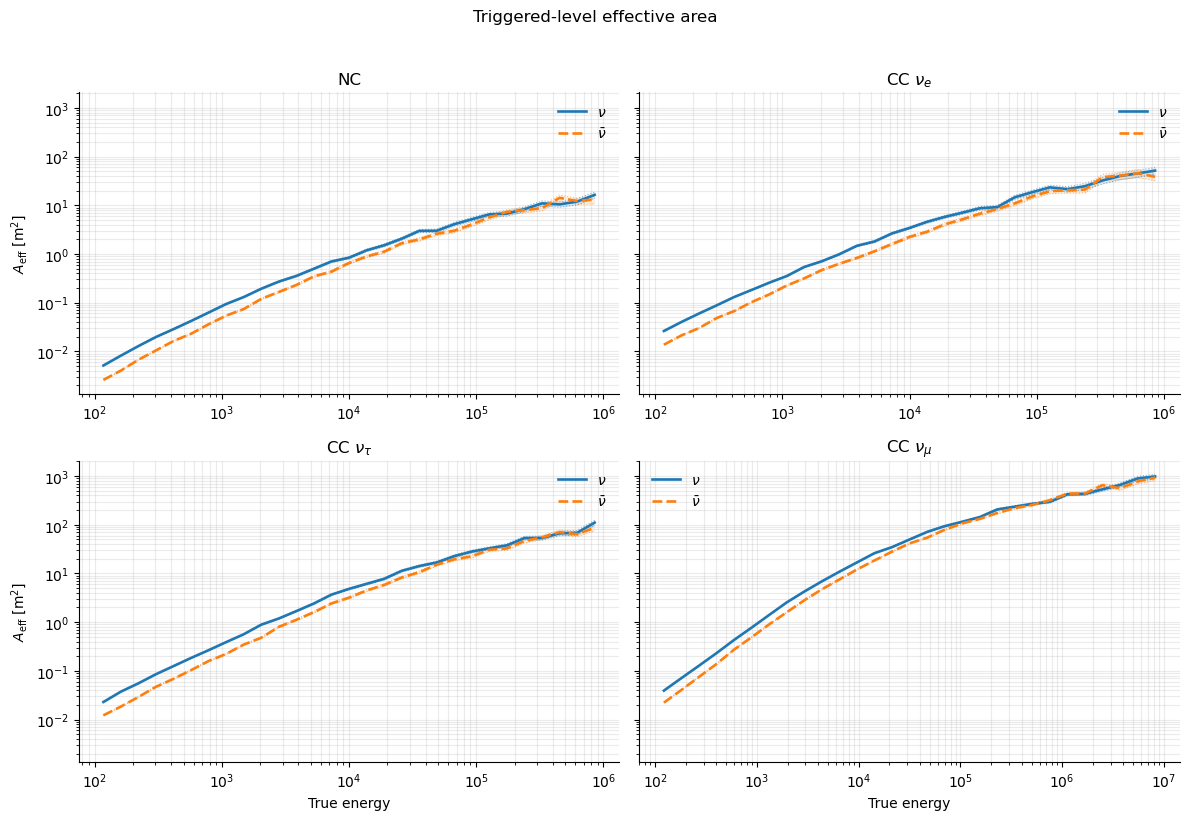

In [143]:
plot_effective_area_by_flavor(
    triggered_weighted_flavor_splits,
    "Triggered-level effective area",
)

## Generation-level effective area

All generated weighted events are used here, before applying the triggered-event selection. Neutrino and antineutrino are shown as separate curves in each flavor panel.

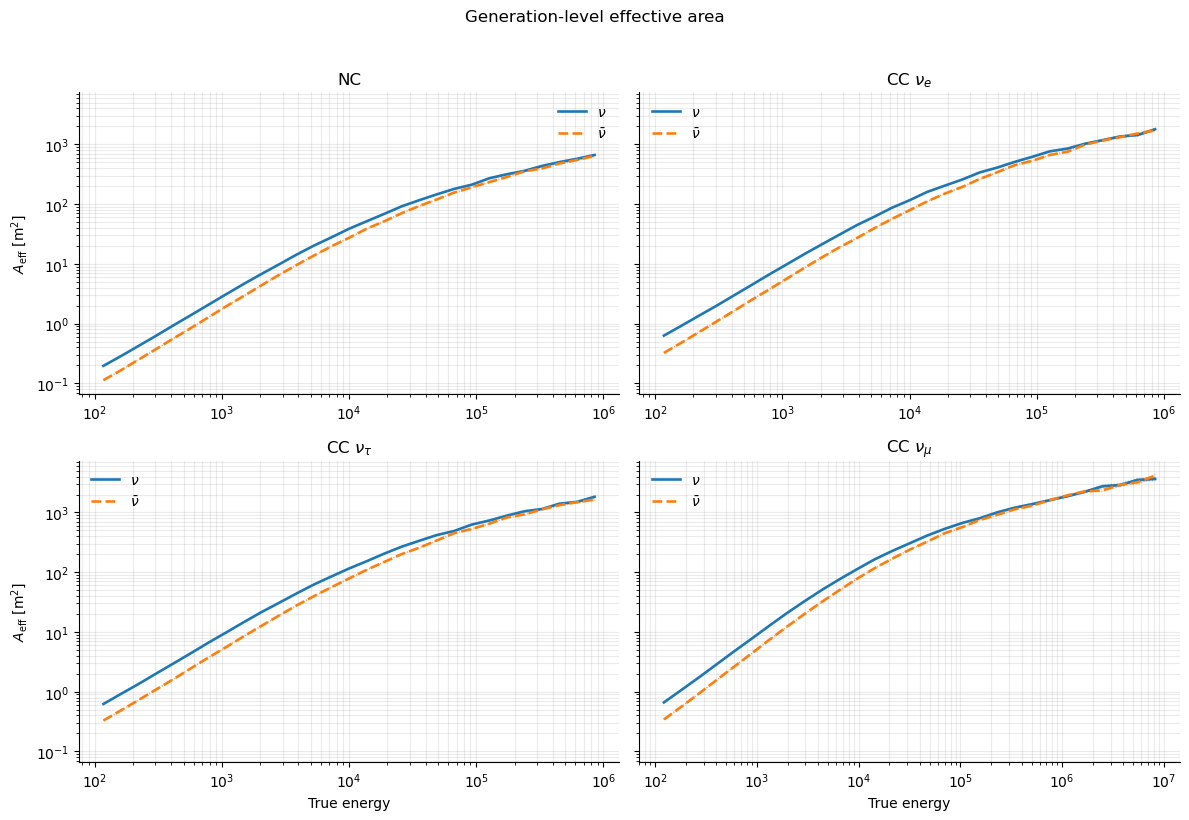

In [144]:
plot_effective_area_by_flavor(
    weighted_flavor_splits,
    "Generation-level effective area",
)

## Triggered and generation-level comparison

Neutrino and antineutrino effective areas are summed within each flavor. The two curves compare the effective area after trigger selection with the generation-level effective area before trigger selection.

In [ ]:
plot_triggered_vs_generation(
    triggered_weighted_flavor_splits,
    weighted_flavor_splits,
    "Triggered vs generation-level effective area",
)

## Relative statistical uncertainty

The absolute $\pm 1\sigma$ MC uncertainty is shown on the effective-area plots as a shaded band with dotted boundaries. Because those bands are narrow on a log-scale effective-area axis, the relative uncertainty $\sigma_{A_{\mathrm{eff}}} / A_{\mathrm{eff}}$ is also shown here.

In [ ]:
plot_relative_uncertainty_triggered_vs_generation(
    triggered_weighted_flavor_splits,
    weighted_flavor_splits,
    "Relative statistical uncertainty",
)

## Triggered effective area by declination band

Neutrino and antineutrino samples are summed within each flavor. The curves show the triggered effective area in `sin(dec)` bands, following the style of the IceCube-Gen2 angular-band effective-area plot.

The detector latitude is taken from the STRAW/P-ONE Cascadia Basin site description, which gives the dark-site location as `47°46' N, 127°46' W`: [STRAW: STRings for Absorption length in Water, Pathfinder for a neutrino telescope in the deep Pacific Ocean](https://www.researchgate.net/publication/331084780_STRAW_STRings_for_Absorption_length_in_Water_Pathfinder_for_a_neutrino_telescope_in_the_deep_Pacific_Ocean). This corresponds to `47.7667 deg` north.

`sin(dec)` is computed from local `zenith` and `azimuth` using this latitude. The stored angles describe the sampled neutrino direction; for sky declination bands we use the incoming/source direction, i.e. the opposite vector, so the computed declination is sign-flipped. Since the generated azimuth is uniform, the unknown absolute azimuth zero-point is assumed not to bias the declination-band populations; it would only rotate a uniform azimuth distribution. This section therefore assumes the standard local azimuth convention for the coordinate conversion.


In [ ]:
DETECTOR_LATITUDE_DEG = 47 + 46 / 60
DETECTOR_LATITUDE_RAD = np.deg2rad(DETECTOR_LATITUDE_DEG)

sin_dec_bands = [
    (0.6, 1.0),
    (0.2, 0.6),
    (-0.2, 0.2),
    (-0.6, -0.2),
    (-1.0, -0.6),
]
sin_dec_band_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]


def add_sin_declination(sample):
    altitude = np.pi / 2 - sample["zenith"]
    sin_dec = (
        np.sin(DETECTOR_LATITUDE_RAD) * np.sin(altitude)
        + np.cos(DETECTOR_LATITUDE_RAD) * np.cos(altitude) * np.cos(sample["azimuth"])
    )

    sample = sample.copy()
    sample["sin_declination"] = -np.clip(sin_dec, -1, 1)
    return sample


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True)
axes = axes.ravel()

for ax, flavor in zip(axes, flavor_plot_order):
    bins = flavor_energy_bins[flavor]
    flavor_sample = pd.concat(
        [
            triggered_weighted_flavor_splits[flavor]["neutrino"],
            triggered_weighted_flavor_splits[flavor]["antineutrino"],
        ],
        ignore_index=True,
    )
    flavor_sample = add_sin_declination(flavor_sample)

    for (low, high), color in zip(sin_dec_bands, sin_dec_band_colors):
        if high == 1.0:
            band_sample = flavor_sample.loc[
                (flavor_sample["sin_declination"] >= low)
                & (flavor_sample["sin_declination"] <= high)
            ]
        else:
            band_sample = flavor_sample.loc[
                (flavor_sample["sin_declination"] >= low)
                & (flavor_sample["sin_declination"] < high)
            ]

        centers, area, uncertainty = calculate_effective_area(band_sample, bins)
        positive = area > 0
        ax.plot(
            centers[positive],
            area[positive],
            color=color,
            linewidth=1.9,
            label=f"({low:.1f}, {high:.1f}]",
        )

    ax.set_title(flavor_display_labels[flavor])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(title=r"$\sin\delta$", frameon=False)

for ax in axes[2:]:
    ax.set_xlabel("True energy")
for ax in axes[::2]:
    ax.set_ylabel(r"$A_{\mathrm{eff},\nu+\bar{\nu}}$ [m$^2$]")

fig.suptitle("Triggered effective area by declination band", y=1.02)
fig.tight_layout()
plt.show()

## Total triggered effective area by declination band

All flavors, neutrinos, and antineutrinos are summed together. The curves show the total triggered effective area in `sin(dec)` bands.

In [ ]:
all_triggered_samples = []

for flavor in flavor_plot_order:
    all_triggered_samples.extend(
        [
            triggered_weighted_flavor_splits[flavor]["neutrino"],
            triggered_weighted_flavor_splits[flavor]["antineutrino"],
        ]
    )

total_triggered_sample = pd.concat(all_triggered_samples, ignore_index=True)
total_triggered_sample = add_sin_declination(total_triggered_sample)
total_energy_bins = make_flavor_energy_bins({"total": total_triggered_sample})

fig, ax = plt.subplots(figsize=(7, 5))

for (low, high), color in zip(sin_dec_bands, sin_dec_band_colors):
    if high == 1.0:
        band_sample = total_triggered_sample.loc[
            (total_triggered_sample["sin_declination"] >= low)
            & (total_triggered_sample["sin_declination"] <= high)
        ]
    else:
        band_sample = total_triggered_sample.loc[
            (total_triggered_sample["sin_declination"] >= low)
            & (total_triggered_sample["sin_declination"] < high)
        ]

    centers, area, uncertainty = calculate_effective_area(band_sample, total_energy_bins)
    positive = area > 0
    ax.plot(
        centers[positive],
        area[positive],
        color=color,
        linewidth=2.2,
        label=f"({low:.1f}, {high:.1f}]",
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("True energy")
ax.set_ylabel(r"$A_{\mathrm{eff},\nu+\bar{\nu}}$ [m$^2$]")
ax.grid(True, which="both", alpha=0.25)
ax.legend(title=r"$\sin\delta$", frameon=False)
plt.tight_layout()
plt.show()